In [23]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [37]:
class MovingAverage():
    """
    Скользящее среднее. Сглаживание
    """
    def __init__(self, size):
        self.size = size
        self.queue = []

    def next(self, val):
        self.queue.append(val)
        if len(self.queue) > self.size:
            self.queue.pop(0)
        return sum(self.queue) / len(self.queue)

In [38]:
fps_csv = "data/fps.csv"

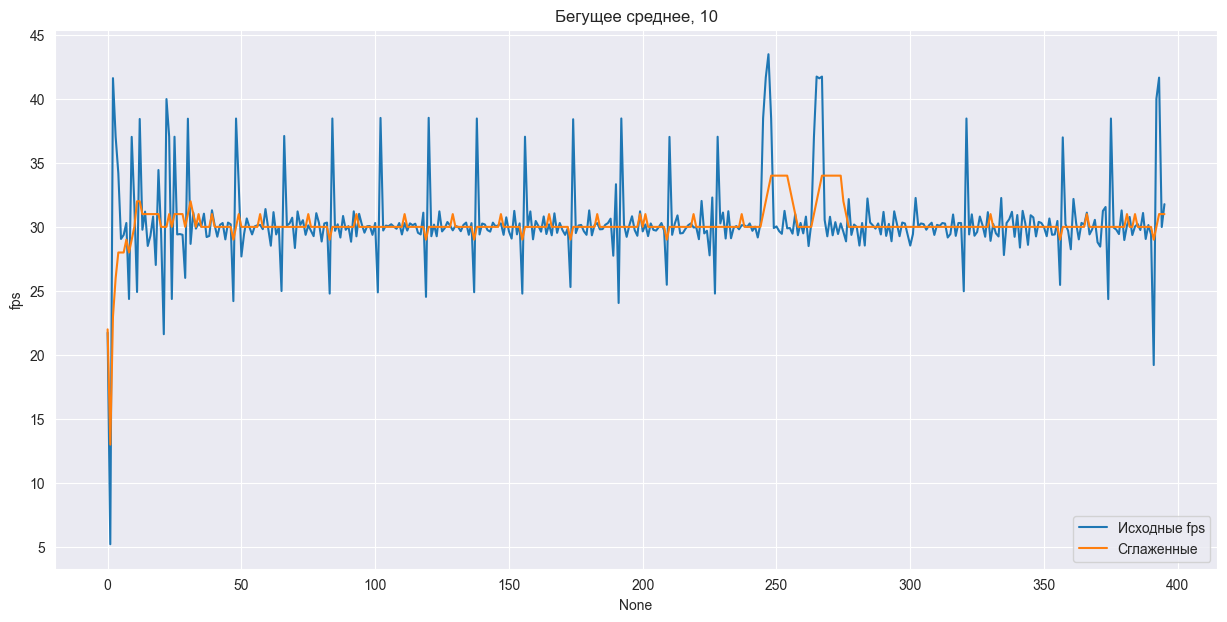

In [39]:
data = pd.read_csv(fps_csv)
# data = pd.read_csv(fps_csv, header=None, names=['fps'])
n_avg = 10
av_fps = MovingAverage(n_avg)
data["av_fps"] = data["fps"].apply(av_fps.next).apply(round)
plt.figure(figsize=(15, 7))
ax = sns.lineplot(x=data.index, y=data["fps"], label="Исходные fps")  # Линия для исходных fps
sns.lineplot(x=data.index, y=data["av_fps"], label="Сглаженные")  # Линия для сглаженных

ax.set_title(f"Бегущее среднее, {n_avg}")
plt.show()